# 01 — Exploratory data analysis: the Green collection

This notebook looks at the data before any model is trained. It answers four questions:

1. What do the images and the annotations look like?
2. Are the annotation masks clean, and what has to be fixed?
3. What do the cells look like (size, shape, brightness, how many per image)?
4. Which design choices of the model follow from these observations?

It also **creates the cleaned masks** used by all the other notebooks (`data/cleaned_masks/`).
Runs on CPU in a few minutes.

## 1. The dataset and the scope of this project

The *Fluorescent Neuronal Cells v2* dataset (Clissa et al., 2024) contains fluorescence microscopy images of rodent brain
slices in three collections. They are not the same experiment in three colours: each one uses a different marker.

| collection | marker | what is stained | annotation masks (trainval / test) | median cell area |
|---|---|---|---|---|
| **Green** | **c-FOS** | **nuclei of recently activated neurons** | **213 / 70 (+ 408 unannotated images)** | **733 px** |
| Yellow | CTb  | neurons projecting to the injection site (tracer) | 213 / 70 | 1292 px |
| Red | Orexin | one neuronal type (orexinergic neurons) | 138 / 46 | 3304 px |

*Counts from the dataset; median areas from the full exploratory analysis of the three collections.*

This project works on **Green only**: c-FOS marks the nucleus, so the objects are small, round and fairly homogeneous, and
one collection can be studied in depth (cleaning, model, post-processing, evaluation) instead of three superficially.
The official split is kept: `trainval` for training and model selection, `test` only for the final evaluation.

In [1]:
import json
import os
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage.io as io
from skimage import measure

# run from the repository root, so that the project packages are importable
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from evaluation.postprocess import MIN_AREA, remove_small   # the same minimum-area rule used on the predictions

DATA = Path("data/green")
CLEAN = Path("data/cleaned_masks")
SPLITS = ["trainval", "test"]

## 2. Loading the data

Each split has an `images/` folder (RGB PNG) and a `ground_truths/masks/` folder (binary PNG), matched by file name.
The official COCO file of each split also gives the number of cells of every image.

In [2]:
files = {}
for split in SPLITS:
    images = sorted(p.name for p in (DATA / split / "images").glob("*.png"))
    masks = sorted(p.name for p in (DATA / split / "ground_truths" / "masks").glob("*.png"))
    files[split] = images
    print(f"{split:8s}: {len(images)} images, {len(masks)} masks | masks without image: {sorted(set(masks) - set(images))} "
          f"| images without mask: {sorted(set(images) - set(masks))}")
print(f"unannotated: {len(list((DATA / 'unlabelled' / 'images').glob('*.png')))} images (not used)")

coco = {split: {a["image_id"] + ".png": a["count"]
                for a in json.load(open(DATA / split / "ground_truths" / "COCO" / f"annotations_green_{split}.json"))["annotations"]}
        for split in SPLITS}

def load_mask(split, name):
    return io.imread(DATA / split / "ground_truths" / "masks" / name)

def load_image(split, name):
    return io.imread(DATA / split / "images" / name)

trainval: 212 images, 213 masks | masks without image: ['128.png'] | images without mask: []
test    : 70 images, 70 masks | masks without image: [] | images without mask: []
unannotated: 408 images (not used)


`128.png` has a mask but no image: it is left out. From here on: **212 trainval images and 70 test images**.

## 3. Visualizing images and masks

Three trainval images: one without cells, one with a few and the most crowded one. The images are dark (the background is
around 30/255), so all three are shown with the same brightness scale (values above 150/255 appear saturated); the annotated
cells are outlined in magenta.

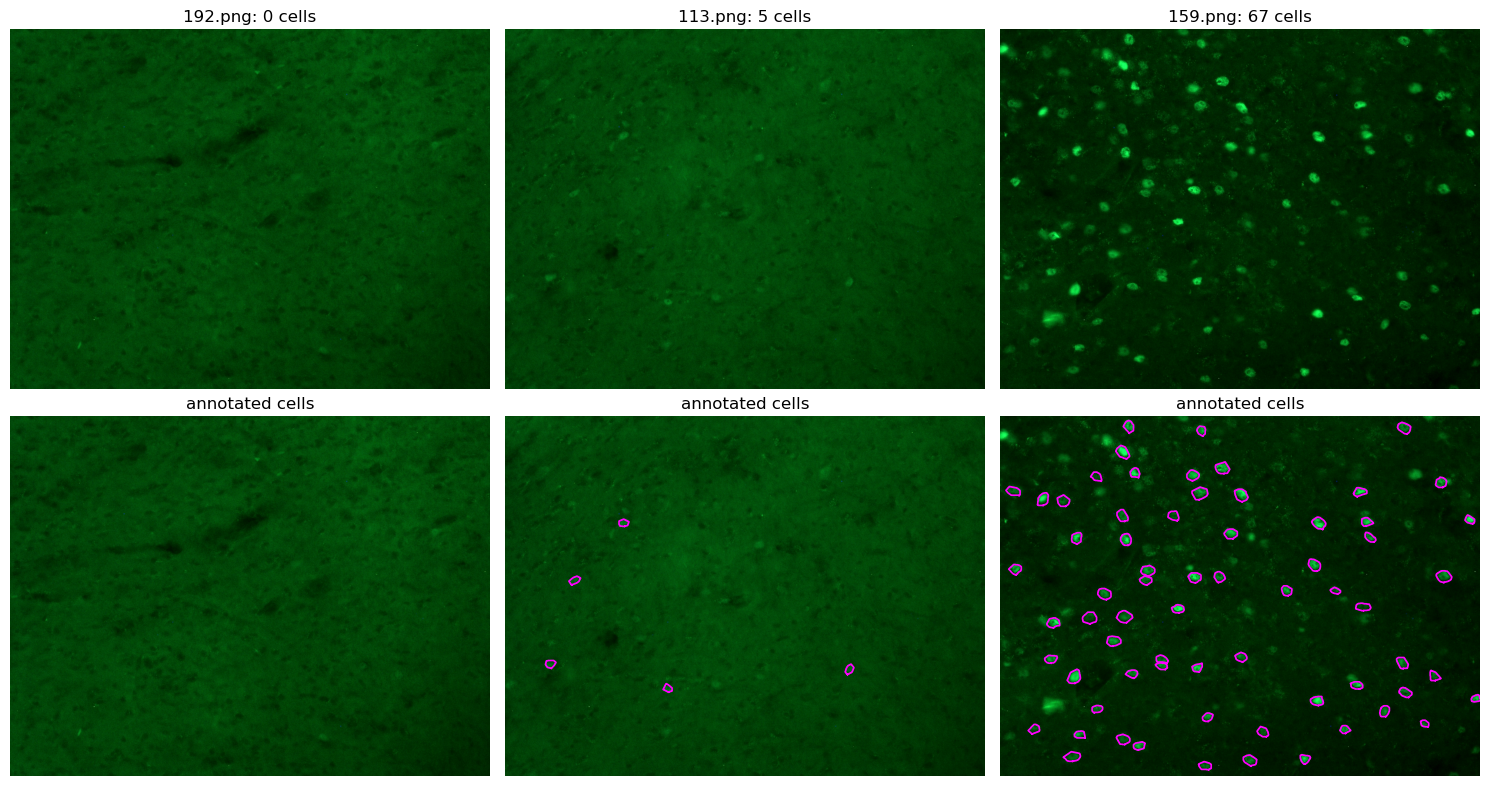

In [3]:
def stretch(img, vmax=None):
    '''Display only: divide by vmax (default: 99.9th percentile of the image) and clip to [0, 1].'''
    vmax = np.percentile(img, 99.9) if vmax is None else vmax
    return np.clip(img / max(vmax, 1), 0, 1)

def outline(ax, mask, color="magenta", lw=1.2):
    for c in measure.find_contours(mask > 0, 0.5):
        ax.plot(c[:, 1], c[:, 0], color=color, linewidth=lw)

n_cells = {n: coco["trainval"][n] for n in files["trainval"]}
examples = [min(n_cells, key=lambda n: (n_cells[n] != 0, n)),          # no cells
            min(n_cells, key=lambda n: (abs(n_cells[n] - 5), n)),      # a few cells
            max(n_cells, key=lambda n: n_cells[n])]                    # most crowded

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, name in enumerate(examples):
    img, mask = load_image("trainval", name), load_mask("trainval", name)
    axes[0, j].imshow(stretch(img, 150)); axes[0, j].set_title(f"{name}: {n_cells[name]} cells")
    axes[1, j].imshow(stretch(img, 150)); outline(axes[1, j], mask); axes[1, j].set_title("annotated cells")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Mask format

A mask should be a single-channel 1200 × 1600 image with only two values: 0 (background) and 255 (cell).

In [4]:
rows = []
for split in SPLITS:
    for p in sorted((DATA / split / "ground_truths" / "masks").glob("*.png")):
        m = io.imread(p)
        rows.append({"split": split, "shape": m.shape, "dtype": str(m.dtype), "values": tuple(int(v) for v in np.unique(m))})
fmt = pd.DataFrame(rows)
fmt.groupby(["split", "shape", "dtype", "values"]).size().rename("N_masks").to_frame()

N_masks
split    shape        dtype values           
test     (1200, 1600) uint8 (0,)            2
                            (0, 255)       68
trainval (1200, 1600) uint8 (0,)            4
                            (0, 255)      209

All masks are single-channel `uint8` images with values {0, 255}; the few masks with only 0 are images without cells.
Nothing to fix in the format.

## 5. Signal 

The images are RGB, but c-FOS fluorescence is green. Mean and standard deviation of each channel over the 212 trainval images:

In [5]:
s, s2, n_px, brightest = np.zeros(3), np.zeros(3), 0, []
max_rb = []
for name in files["trainval"]:
    img = load_image("trainval", name)
    x = img.reshape(-1, 3).astype(np.float64) / 255
    s += x.sum(0); s2 += (x ** 2).sum(0); n_px += len(x)
    brightest.append(int(x.mean(0).argmax()))
    max_rb.append((img[..., 0].max(), img[..., 2].max()))
ch_mean, ch_std = s / n_px, np.sqrt(s2 / n_px - (s / n_px) ** 2)
g_mean = s.sum() / (3 * n_px); g_std = np.sqrt(s2.sum() / (3 * n_px) - g_mean ** 2)


print(pd.DataFrame({"mean": ch_mean, "std": ch_std}, index=["R", "G", "B"]).round(4).to_string())
print(f"\nbrightest channel per image: {pd.Series(brightest).map({0: 'R', 1: 'G', 2: 'B'}).value_counts().to_dict()}")
r_max, b_max = np.max(max_rb, axis=0) / 255
print(f"brightest R pixel {r_max:.2f}, brightest B pixel {b_max:.2f} (rare artefacts)")
print(f"\nper-channel normalization, z of those pixels: R {(r_max - ch_mean[0]) / ch_std[0]:.0f}, B {(b_max - ch_mean[2]) / ch_std[2]:.0f}")
print(f"one global mean/std ({g_mean:.4f} / {g_std:.4f}): all values between {(0 - g_mean) / g_std:.2f} and {(1 - g_mean) / g_std:.2f}")

     mean     std
R  0.0029  0.0047
G  0.1339  0.0618
B  0.0120  0.0151

brightest channel per image: {'G': 212}
brightest R pixel 0.83, brightest B pixel 0.83 (rare artefacts)

per-channel normalization, z of those pixels: R 175, B 54
one global mean/std (0.0496 / 0.0702): all values between -0.71 and 13.54


- **The signal is in G.** R and B are almost empty (means below 0.015) and G is the brightest channel in every image.
  A generic `rgb → gray` conversion (0.21 R + 0.72 G + 0.07 B) is designed for photographs and would only rescale G and mix
  in the noise of the other channels; when a single channel is needed (baselines, intensity measures) we take G.
- **Normalization.** Normalizing each channel separately would divide the near-empty R and B by tiny standard deviations and
  turn rare artefact pixels into huge values (z in the hundreds). One **global** mean and standard deviation over the three
  channels keeps every value in a small range and keeps the ratio between channels. The network still receives RGB and its
  first layer (a 1 × 1 convolution) learns how to combine the channels.

## 6. Objects in the masks: connectivity

To count cells, a mask is split into connected components. Two pixels belong to the same object if they touch on a side
(**connectivity 4**) or also on a corner (**connectivity 8**). Objects smaller than 150 px are suspicious (the typical cell
is ~730 px):

In [6]:
def object_areas(mask, connectivity):
    '''(label image, area of each object) of a binary mask.'''
    lab = measure.label(mask > 0, connectivity=connectivity)
    return lab, np.bincount(lab.ravel())[1:]

small = []
for split in SPLITS:
    for name in files[split]:
        mask = load_mask(split, name)
        for conn in (1, 2):
            lab, areas = object_areas(mask, conn)
            for k in np.flatnonzero(areas < 150):
                small.append({"split": split, "image": name, "connectivity": 4 if conn == 1 else 8, "area": int(areas[k]),
                              "bbox": measure.regionprops((lab == k + 1).astype(int))[0].bbox})
small = pd.DataFrame(small)
print(small.groupby(["connectivity", "split"]).agg(objects=("area", "size"), images=("image", "nunique"),
                                                   max_area=("area", "max")))

print("\nwith connectivity 8:\n" + small[small.connectivity == 8][["split", "image", "area"]].to_string(index=False))

                       objects  images  max_area
connectivity split                              
4            test            4       4         2
             trainval       13      10       126
8            trainval        1       1       126

with connectivity 8:
   split  image  area
trainval 87.png   126


With connectivity 4 there are 16 tiny objects of 1–2 px plus one object of 126 px; with connectivity 8 only the 126 px object
is left. Two close-ups explain why.

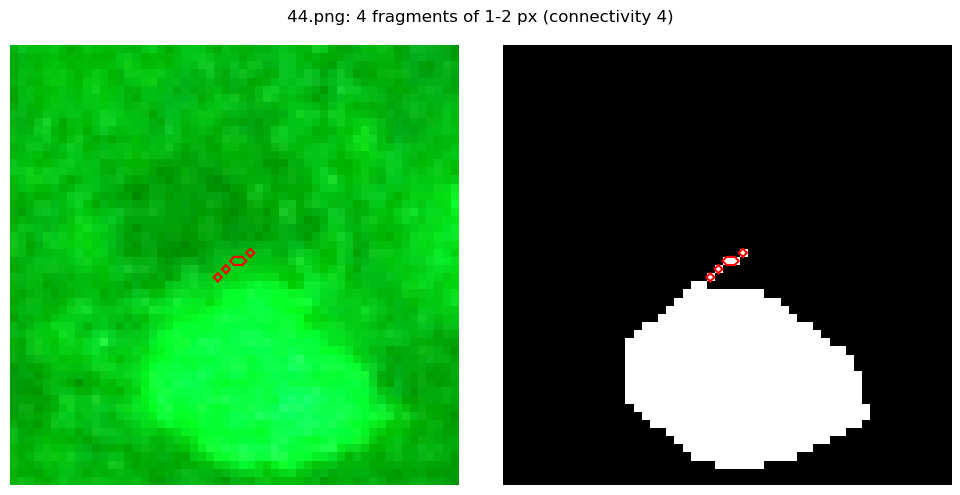

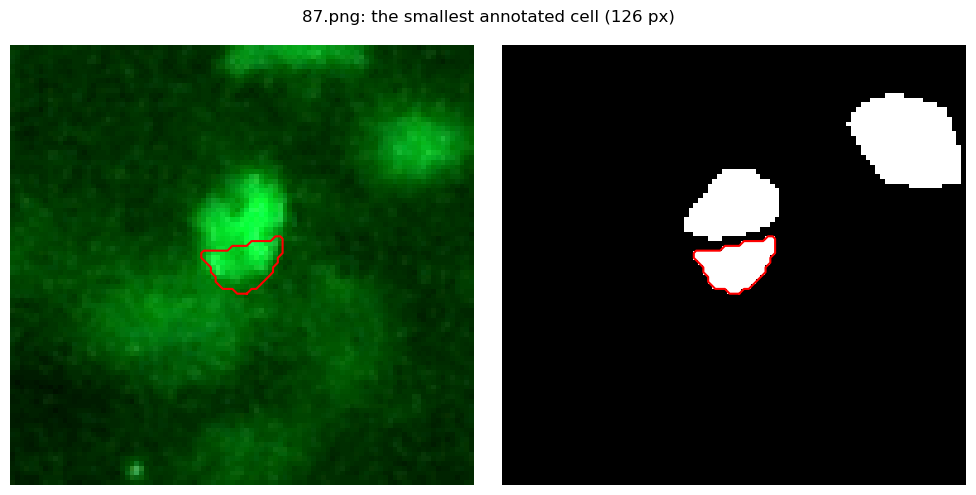

In [7]:
def show_objects(split, name, bboxes, margin=25, title=""):
    '''Image and mask cropped around some objects (given by their bounding boxes, connectivity 4), outlined in red.'''
    img, mask = load_image(split, name), load_mask(split, name)
    r0 = max(min(b[0] for b in bboxes) - margin, 0); c0 = max(min(b[1] for b in bboxes) - margin, 0)
    r1 = min(max(b[2] for b in bboxes) + margin, mask.shape[0]); c1 = min(max(b[3] for b in bboxes) + margin, mask.shape[1])
    lab = measure.label(mask > 0, connectivity=1)
    sel = np.isin(lab, [p.label for p in measure.regionprops(lab) if p.bbox in set(map(tuple, bboxes))])
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(stretch(img)[r0:r1, c0:c1]); axes[1].imshow(mask[r0:r1, c0:c1], cmap="gray")
    for ax in axes:
        outline(ax, sel[r0:r1, c0:c1], color="red", lw=1.5); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

frag = small[(small.connectivity == 4) & (small.image == "44.png")]
show_objects("trainval", "44.png", list(frag.bbox), title=f"44.png: {len(frag)} fragments of 1-2 px (connectivity 4)")
cell = small[(small.connectivity == 8)].iloc[0]
show_objects(cell.split, cell.image, [cell.bbox], margin=40, title=f"{cell.image}: the smallest annotated cell ({cell.area} px)")

- The **fragments** sit along the staircase-shaped diagonal edge of a cell: when the annotators' polygons were turned into
  pixels, a few isolated pixels touch the cell only on a corner. With connectivity 4 they become separate "cells"; with
  connectivity 8 they rejoin the cell.
- The **126 px object** is a genuine cell, faint and with low contrast, next to a brighter one (checked on the image): the
  smallest annotated cell.
- Connectivity 8 would hide the fragments, but it would also merge two different cells touching on a corner, an error that
  cannot be undone later. So: **connectivity 4 + remove objects smaller than 120 px.** For the masks the exact value does not
  matter: the fragments are at most 2 px and the smallest cell is 126 px, so any value between 3 and 126 px gives the same
  cleaned masks. The same rule (`remove_small`, 120 px) is later used on the predictions.

## 7. Cleaning

In [8]:
cleaned, impact = {}, []
for split in SPLITS:
    for name in sorted(p.name for p in (DATA / split / "ground_truths" / "masks").glob("*.png")):
        orig = load_mask(split, name) > 0
        clean = remove_small(orig, MIN_AREA, connectivity=1)
        cleaned[split, name] = clean
        impact.append({"split": split, "image": name,
                       "objects_removed": int(measure.label(orig, connectivity=1).max() - measure.label(clean, connectivity=1).max()),
                       "px_removed": int(orig.sum() - clean.sum()), "px_added": int((clean & ~orig).sum())})
impact = pd.DataFrame(impact)
assert impact.px_added.sum() == 0, "cleaning must only remove pixels"
print(impact.groupby("split").agg(masks=("image", "size"), images_changed=("objects_removed", lambda s: int((s > 0).sum())),
                                  objects_removed=("objects_removed", "sum"), px_removed=("px_removed", "sum")).to_string())

          masks  images_changed  objects_removed  px_removed
split                                                       
test         70               4                4           6
trainval    213               9               12          15


The cleaning removes only the 16 fragments (21 pixels in total) and never adds a pixel. The test masks are cleaned with the same rule, so that training and evaluation count cells in the same way.

## 8. Checks against the official counts

In [9]:
checks = []
for split in SPLITS:
    for name in files[split]:
        orig, clean = load_mask(split, name) > 0, cleaned[split, name]
        checks.append({"split": split, "image": name, "coco": coco[split][name],
                       "orig_conn4": measure.label(orig, connectivity=1).max(),
                       "clean_conn4": measure.label(clean, connectivity=1).max(),
                       "clean_conn8": measure.label(clean, connectivity=2).max()})
checks = pd.DataFrame(checks)
summary = checks.groupby("split").agg(
    images=("image", "size"), cells_coco=("coco", "sum"), cells_clean=("clean_conn4", "sum"),
    mismatch_before=("orig_conn4", lambda s: int((s != checks.loc[s.index, "coco"]).sum())),
    mismatch_after=("clean_conn4", lambda s: int((s != checks.loc[s.index, "coco"]).sum())),
    conn4_vs_conn8=("clean_conn8", lambda s: int((s != checks.loc[s.index, "clean_conn4"]).sum())))
print(summary.to_string())
assert (checks.clean_conn4 == checks.coco).all() and (checks.clean_conn4 == checks.clean_conn8).all()

          images  cells_coco  cells_clean  mismatch_before  mismatch_after  conn4_vs_conn8
split                                                                                     
test          70        1172         1172                4               0               0
trainval     212        3421         3421                9               0               0


- Before cleaning, 13 images disagree with the official count (the fragments are counted as cells); after cleaning,
  **every image agrees** with the COCO count: 3421 cells in trainval, 1172 in test.
- Connectivity 4 and 8 give the same objects on the cleaned masks: **no two annotated cells touch**, not even on a corner.

## 9. Saving the cleaned masks

Same layout used by the training and evaluation code: `data/cleaned_masks/{trainval,test}/Green/masks/<name>.png`, values
0/255, plus one zip per split (Green only) for uploading to Kaggle.

In [10]:
for (split, name), clean in cleaned.items():
    out = CLEAN / split / "Green" / "masks"
    out.mkdir(parents=True, exist_ok=True)
    io.imsave(out / name, clean.astype(np.uint8) * 255, check_contrast=False)
for split in SPLITS:
    shutil.make_archive(str(Path("data") / f"cleaned_masks_{split}"), "zip", root_dir=CLEAN / split)

# read back: identical to what was computed
assert all(np.array_equal(io.imread(CLEAN / s / "Green" / "masks" / n) > 0, c) for (s, n), c in cleaned.items())
print({split: len(list((CLEAN / split / "Green" / "masks").glob("*.png"))) for split in SPLITS}, "masks written")

{'trainval': 213, 'test': 70} masks written


## 10. Cells Statistics

Shape and brightness of the 3421 trainval cells (cleaned masks; intensity measured on G; contrast = mean intensity of the
cell divided by the median of its image, i.e. how much brighter than the background).

          area  equivalent_diameter  feret_max  solidity  eccentricity  intensity  contrast
count  3421.00              3421.00    3421.00   3421.00       3421.00    3421.00   3421.00
mean    766.48                30.85      39.01      0.96          0.67      65.83      2.27
std     246.65                 4.90       6.27      0.02          0.14      20.24      0.84
min     126.00                12.67      17.46      0.76          0.16      25.33      0.93
1%      336.20                20.69      25.71      0.90          0.29      32.75      1.20
50%     733.00                30.55      38.59      0.96          0.69      62.19      2.05
99%    1523.00                44.04      55.08      0.98          0.90     129.02      5.26
max    2306.00                54.19      67.60      0.99          0.94     172.79      8.31


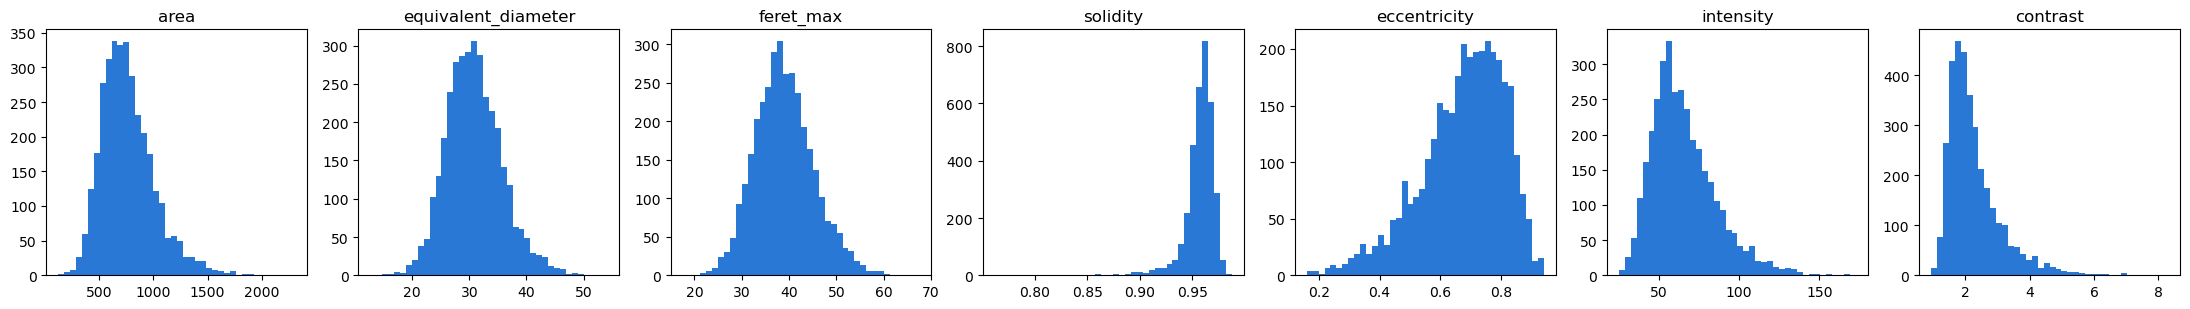

In [11]:
cells = []
for name in files["trainval"]:
    g = load_image("trainval", name)[..., 1].astype(np.float32)
    lab = measure.label(cleaned["trainval", name], connectivity=1)
    background = float(np.median(g))
    for p in measure.regionprops(lab, intensity_image=g):
        r0, c0, r1, c1 = p.bbox
        cells.append({"image": name, "area": p.area, "equivalent_diameter": p.equivalent_diameter_area,
                      "feret_max": p.feret_diameter_max, "solidity": p.solidity, "eccentricity": p.eccentricity,
                      "intensity": p.intensity_mean, "contrast": p.intensity_mean / max(background, 1)})
cells = pd.DataFrame(cells)
cols = ["area", "equivalent_diameter", "feret_max", "solidity", "eccentricity", "intensity", "contrast"]
print(cells[cols].describe(percentiles=[0.01, 0.5, 0.99]).round(2).to_string())

fig, axes = plt.subplots(1, len(cols), figsize=(22, 3.2))
for ax, c in zip(axes, cols):
    ax.hist(cells[c], bins=40, color="#2a78d6"); ax.set_title(c)
plt.tight_layout(); plt.show()

- **Size:** median area 733 px, mean equivalent diameter ~31 px, largest extent (Feret) at most 68 px; 99% of the cells are
  larger than ~340 px, far above the 120 px threshold.
- **Shape:** compact and round (solidity 0.96), moderately elongated (eccentricity ~0.7).
- **Brightness:** the contrast spans a wide range (1% of the cells are barely brighter than the background, 1.2×; the median
  is 2×). Faint cells are where annotators have to decide "cell or not": the protocol of the dataset asks for a conservative
  choice in doubtful cases, a first hint that the hardest part of the task is in the labels themselves.

## 11. Per image cells counting

{'count': 212.0, 'mean': 16.1, 'std': 13.8, 'min': 0.0, '25%': 6.0, '50%': 12.0, '75%': 22.0, 'max': 67.0} | images without cells: 4
quartiles: {0.25: 6.0, 0.5: 12.0, 0.75: 22.0}
random 512 x 512 crops that contain at least one cell: 76%


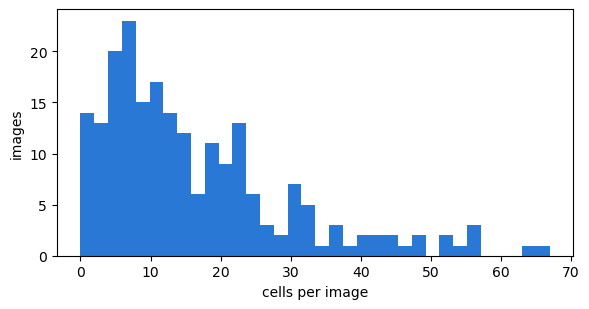

In [12]:
per_image = pd.Series({n: coco["trainval"][n] for n in files["trainval"]})
print(per_image.describe().round(1).to_dict(), "| images without cells:", int((per_image == 0).sum()))
print("quartiles:", per_image.quantile([0.25, 0.5, 0.75]).to_dict())

rng = np.random.default_rng(0)
has_cells = []
for name in files["trainval"]:
    m = cleaned["trainval", name]
    for _ in range(20):
        t, l = rng.integers(0, 1200 - 512 + 1), rng.integers(0, 1600 - 512 + 1)
        has_cells.append(m[t:t + 512, l:l + 512].any())
print(f"random 512 x 512 crops that contain at least one cell: {100 * np.mean(has_cells):.0f}%")

plt.figure(figsize=(6, 3.2)); plt.hist(per_image, bins=34, color="#2a78d6")
plt.xlabel("cells per image"); plt.ylabel("images"); plt.tight_layout(); plt.show()

From 0 to 67 cells per image, skewed to the right (median 12). A random split could put, by chance, mostly empty or mostly
crowded images in the validation set, so the split is **stratified by quartiles of the number of cells**.
Three random 512 × 512 crops out of four already contain cells: training on uniform random crops is enough, without
sampling around the cells (the 0.6% of cell pixels is handled by the loss).




## 13. Brightness differences between images

In [13]:
img_stats = []
for name in files["trainval"]:
    g = load_image("trainval", name)[..., 1].astype(np.float32)
    m = cleaned["trainval", name]
    img_stats.append({"background": float(np.median(g)), "cells": float(g[m].mean()) if m.any() else np.nan})
img_stats = pd.DataFrame(img_stats)
for c in ["background", "cells"]:
    q = img_stats[c].dropna()
    print(f"{c:10s}: 5th percentile {q.quantile(0.05) / q.median():.2f} x median, 95th percentile {q.quantile(0.95) / q.median():.2f} x median")

background: 5th percentile 0.60 x median, 95th percentile 1.90 x median
cells     : 5th percentile 0.73 x median, 95th percentile 1.55 x median


The mean brightness of the cells changes from image to image: between 0.73 and 1.55 times the median image (5th–95th
percentile). The brightness augmentation of the training (a random gain in **[0.75, 1.5]**) reproduces this range.

## 14. From observations to design choices

| observation | choice |
|---|---|
| signal only in G; R and B almost empty with rare bright artefacts | RGB input, **one global** mean and std (computed on the training images) |
| 1–2 px fragments from the polygon rasterization; no annotated cells touching | **connectivity 4**; objects < 120 px removed from the masks (predictions: < 300 px, notebook 03) | 
| cells 31 px wide, at most 68 px | receptive field of the network (~96 px) larger than the largest cell, so the network sees each cell with its surroundings | 
| 0–67 cells per image, skewed | split and folds **stratified by number of cells** | 
| 76% of random 512 px crops contain cells | uniform random crops of 512 × 512 | 
| cell brightness varies 0.73–1.55× between images | brightness augmentation, gain in [0.75, 1.5] (+ gamma, + flips and 90° rotations) | 
| faint cells (contrast down to ~1.2×) | the yes/no decision on faint cells is the hard part: --> needs an object classifier | 